In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
# ─────────────────────────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────────────────────────

df = pd.read_csv("augmented_dataset.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# Identify text column
text_col = "text_" if "text_" in df.columns else "text"

Dataset Shape: (41032, 7)

Columns: ['category', 'rating', 'label', 'text_', 'user_id', 'date', 'source']


In [3]:
# ─────────────────────────────────────────────────────────────
# BASIC DISTRIBUTIONS
# ─────────────────────────────────────────────────────────────

print("\n--- Label Distribution ---")
print(df["label"].value_counts())

print("\n--- Source Distribution ---")
print(df["source"].value_counts())

print("\n--- Cross Distribution ---")
print(pd.crosstab(df["source"], df["label"]))



--- Label Distribution ---
label
CG    20616
OR    20416
Name: count, dtype: int64

--- Source Distribution ---
source
original          40432
synthetic_groq      600
Name: count, dtype: int64

--- Cross Distribution ---
label              CG     OR
source                      
original        20216  20216
synthetic_groq    400    200



--- Word Count Stats ---
                  count       mean        std   min   25%   50%   75%    max
source                                                                      
original        40432.0  67.308716  69.562949   1.0  21.0  38.0  85.0  373.0
synthetic_groq    600.0  63.545000  25.911973  20.0  41.0  63.0  89.0  122.0


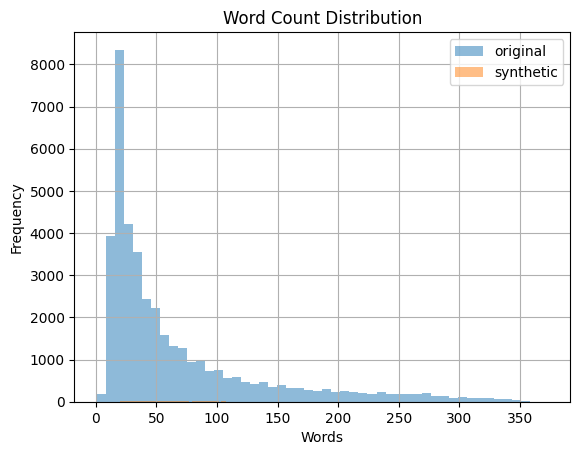

In [5]:
# ─────────────────────────────────────────────────────────────
# TEXT LENGTH ANALYSIS
# ─────────────────────────────────────────────────────────────

df["word_count"] = df[text_col].astype(str).apply(lambda x: len(x.split()))
df["char_count"] = df[text_col].astype(str).apply(len)

print("\n--- Word Count Stats ---")
print(df.groupby("source")["word_count"].describe())

# Plot word count distribution
plt.figure()
df[df["source"]=="original"]["word_count"].hist(alpha=0.5, bins=50, label="original")
df[df["source"]=="synthetic_groq"]["word_count"].hist(alpha=0.5, bins=50, label="synthetic")
plt.legend()
plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()


In [6]:
# ─────────────────────────────────────────────────────────────
# DUPLICATE CHECK
# ─────────────────────────────────────────────────────────────

duplicates = df.duplicated(subset=[text_col]).sum()
print(f"\nDuplicate reviews: {duplicates}")


Duplicate reviews: 137


In [7]:
# ─────────────────────────────────────────────────────────────
# VOCABULARY ANALYSIS
# ─────────────────────────────────────────────────────────────

def top_words(texts, n=20):
    words = " ".join(texts).lower().split()
    return Counter(words).most_common(n)

print("\n--- Top Words (Original) ---")
print(top_words(df[df["source"]=="original"][text_col]))

print("\n--- Top Words (Synthetic) ---")
print(top_words(df[df["source"]=="synthetic_groq"][text_col]))


--- Top Words (Original) ---
[('the', 156340), ('a', 96519), ('i', 96219), ('and', 86965), ('to', 67959), ('is', 64153), ('it', 57279), ('this', 47900), ('of', 45284), ('for', 38403), ('in', 28929), ('was', 26052), ('that', 25859), ('my', 24546), ('with', 23153), ('have', 22931), ('very', 20550), ('but', 20224), ('are', 18901), ('not', 18734)]

--- Top Words (Synthetic) ---
[('the', 1872), ('and', 1616), ('a', 1283), ('my', 1180), ('is', 890), ('i', 826), ('to', 752), ('for', 708), ("it's", 548), ('this', 538), ("i've", 530), ('it', 497), ("i'm", 484), ('with', 434), ('been', 394), ('of', 383), ('in', 362), ('-', 289), ('but', 273), ('that', 257)]


In [7]:
# ─────────────────────────────────────────────────────────────
# RANDOM SAMPLE INSPECTION (CRITICAL)
# ─────────────────────────────────────────────────────────────

print("\n--- SAMPLE SYNTHETIC PROMOTIONAL ---")
print(df[(df["source"]=="synthetic_groq") & (df["label"]=="CG")][text_col].sample(3).values)

print("\n--- SAMPLE SYNTHETIC GENUINE ---")
print(df[(df["source"]=="synthetic_groq") & (df["label"]=="OR")][text_col].sample(3).values)

print("\n--- SAMPLE ORIGINAL ---")
print(df[df["source"]=="original"][text_col].sample(3).values)


--- SAMPLE SYNTHETIC PROMOTIONAL ---
["I am absolutely blown away by this yoga mat - the vibrant colors and fun design make even the most mundane yoga practice a joyful experience. The grip is exceptional, providing confidence and stability with every pose. The material is surprisingly durable and easy to clean, withstanding even my most intense vinyasa flows. I adore the thickness - it's perfect for providing cushioning without feeling bulky. One minor complaint is that it does tend to slip a bit on harder surfaces, but overall, this yoga mat has genuinely elevated my home practice and I couldn't be happier with the purchase."
 "I've been struggling with neck and shoulder pain for months, so when I found this memory foam pillow I was a little skeptical at first, but after a week of using it, my pain has significantly decreased. The pillow conforms perfectly to the shape of my head and neck, providing just the right amount of support. The cover is soft and breathable, which is great f

In [8]:
# ─────────────────────────────────────────────────────────────
# HEURISTIC SIGNAL CHECK (OPTIONAL BUT USEFUL)
# ─────────────────────────────────────────────────────────────

df["exclamation_count"] = df[text_col].astype(str).apply(lambda x: x.count("!"))
df["caps_ratio"] = df[text_col].astype(str).apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)
)

print("\n--- Heuristic Signals ---")
print(df.groupby("source")[["exclamation_count", "caps_ratio"]].mean())



--- Heuristic Signals ---
                exclamation_count  caps_ratio
source                                       
original                 0.399659    0.030760
synthetic_groq           0.115000    0.017081


In [9]:
# ─────────────────────────────────────────────────────────────
# FINAL SANITY CHECK
# ─────────────────────────────────────────────────────────────

print("\n--- FINAL CHECK ---")
print("Synthetic %:", len(df[df["source"]=="synthetic_groq"]) / len(df) * 100)
print("Unique texts:", df[text_col].nunique())

print("\nEDA COMPLETE")


--- FINAL CHECK ---
Synthetic %: 1.4622733476311172
Unique texts: 40895

EDA COMPLETE


In [10]:
df[df["source"]=="synthetic_groq"].sample(5)["text_"]

19042    I've had this smart water bottle for a few wee...
28631    I was blown away by the incredible quality of ...
27263    I've had mixed experiences with laptop stands ...
7923     3.0 out of 5 stars I'm kinda meh about these w...
5941     i'm absolutely blown away by this gaming mouse...
Name: text_, dtype: object

In [1]:
import pandas as pd

# Load the original dataset
df = pd.read_csv('fake_reviews_dataset.csv')

# Select the 'text_' and 'label' columns and rename 'text_' to 'text'
new_df = df[['text_', 'label']].rename(columns={'text_': 'text'})

# Save the result to a new CSV file without the index
new_df.to_csv('processed_fake_reviews.csv', index=False)

print("New CSV file created successfully.")

New CSV file created successfully.
